In [201]:
#################################
## 현재 전체 항적 패턴묘사 보고서 ##
#################################
# !{sys.executable} -m pip install datashader

In [1]:
# 1. 기본 시스템 및 데이터 처리
import os
import sys
import warnings
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from getpass import getpass
import json

# 2. 지리 정보 및 기하학적 처리 (GIS)
import shapely as shp
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon, MultiPoint, box
from geopandas import GeoDataFrame, read_file
from geopy.distance import great_circle

# 3. 선박 궤적 분석 (MovingPandas)
import movingpandas as mpd

# 4. 머신러닝 및 데이터 분석
from sklearn.cluster import DBSCAN

# 5. 시각화 (Matplotlib & HoloViews/hvPlot)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import hvplot.pandas
from holoviews import opts, dim, Layout 
import holoviews as hv
# 6. 경고 메시지 무시 설정
warnings.simplefilter("ignore")

# (선택 사항) 커스텀 모듈 경로 추가
sys.path.append("..")


D:\LEE\AI_team\github\Vision_AI_RnD_team\projects\env\env_notebook\Lib\site-packages\movingpandas\__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


In [2]:
## hvplot 셋업
warnings.filterwarnings("ignore")

plot_defaults = {"linewidth": 5, "capstyle": "round", "figsize": (9, 3), "legend": True}
opts.defaults(opts.Overlay(active_tools=["wheel_zoom"]))
hvplot_defaults = {
    "tiles": "CartoLight",
    "frame_height": 320,
    "frame_width": 320,
    "cmap": "Viridis",
    "colorbar": True,
}

In [6]:
## 데이터 불러오기 및 한반도 남해 지역 데이터 필터링

ais_df = pd.read_csv("D:/LEE/AI_team/github/Vision_AI_RnD_team/projects/notebook/기상데이터/Sample01_AIS_new_category_final.csv") 

min_lon, max_lon = 125.678, 131.229
max_lat = 36.001

ais_df_filtered = ais_df[
    (ais_df['longitude'] >= min_lon) & (ais_df['longitude'] <= max_lon) & (ais_df['latitude'] <= max_lat)
]


ais = ais_df_filtered

# if filtering by "timestamp" 
start_time = "2022-12-01 00:00:00"
end_time = "2022-12-02 12:00:00"
time_diff = pd.to_datetime(end_time) - pd.to_datetime(start_time)

# Dataframe을 GeoDataFrame으로 전환
ais = gpd.GeoDataFrame(
    # compressed_once_df,
    ais,
    geometry = gpd.points_from_xy(ais.longitude, ais.latitude),
    crs="EPSG:4326"
)

#시간 인덱스 설정 및 속도 0이상인 항적만 추출
ais['t'] = pd.to_datetime(ais['timestamp'], format='mixed', utc=True)
ais = ais.set_index('t')
ais = ais[(ais['timestamp']>= start_time)&(ais['timestamp'] <= end_time)]
# ais = ais[ais.speed>0]


In [7]:
##########################################################
## DBSCAN Clustering & OD(origin-destination) Flow 분석 ##
##########################################################

# cluster 분석을 위한 전처리
MIN_LENGTH = 1000 # in meters; 1000m 이상인 항적들만 추출
TRIP_ID = 'mmsi'
traj_collection = mpd.TrajectoryCollection(ais, TRIP_ID, min_length=MIN_LENGTH)
traj_collection = mpd.DouglasPeuckerGeneralizer(traj_collection).generalize(tolerance=0.001) #가장 빠름
# traj_collection = mpd.TopDownTimeRatioGeneralizer(traj_collection).generalize(tolerance=0.003) #느림
# traj_collection = mpd.MinTimeDeltaGeneralizer(traj_collection).generalize(tolerance=timedelta(minutes=3))
traj_collection = mpd.DouglasPeuckerGeneralizer(traj_collection).generalize(tolerance=0.001)
trips = mpd.ObservationGapSplitter(traj_collection).split(gap=timedelta(minutes=120)) #60분 이산 정박한 경우 trajectory 분할

print("Finished creating {} trajectories".format(len(traj_collection)))
print("Extracted {} individual trips from {} continuous vessel tracks".format(len(trips), len(traj_collection)))

Finished creating 63 trajectories
Extracted 82 individual trips from 63 continuous vessel tracks


In [8]:
# cluster 분석을 위한 기본 파라미터값 정의
KMS_PER_RADIAN = 6371.0088
EPSILON = 3.0 / KMS_PER_RADIAN 

In [9]:
# 항적 통합 및 단순화
aggregator = mpd.TrajectoryCollectionAggregator(trips, max_distance=100000, min_distance=2000, min_stop_duration=timedelta(minutes=120))

flows = aggregator.get_flows_gdf()
clusters = aggregator.get_clusters_gdf()

In [10]:
# 결과 시각화
flows_plot = flows.hvplot(title='Generalized aggregated trajectories', 
              geo=True, hover_cols=['weight'], 
              line_width='weight', alpha=0.5, 
              color='#1f77b3', tiles='OSM', frame_height=300, 
              frame_width=400)
cluster_plot = clusters.hvplot(geo=True, color='red', size='n') 

flows_plot * cluster_plot 

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Path.I   :Path   [Longitude,Latitude]   (weight)
   .Points.I :Points   [Longitude,Latitude]   (n)

In [11]:
################################################
### LLM 활용을 통한 항적 패턴 요약을 위한 전처리 ###
################################################

### 전체 항적 패턴 요약에 사용할 해상 구역 정의
zone_configs = {
    # --- [Layer 1: 북부 연안 및 울산] Lat: 34.70 ~ 36.00 (일부 34.40 시작) ---
    'Zone_16':   [125.00, 34.40, 125.50, 36.00, '서해 남부 외해'],
    'Zone_5':    [125.50, 34.40, 126.60, 36.00, '목포-신안 해역'],
    'Zone_12':   [126.60, 34.40, 127.60, 36.00, '고흥-완도 연안'],
    'Zone_3':    [127.60, 34.70, 128.00, 36.00, '광양-여수 해역'],
    'Zone_4':    [128.00, 34.70, 128.30, 36.00, '남해 중앙 연안'],
    'Zone_2':    [128.30, 34.70, 128.70, 36.00, '거제-통영 해역'],
    'Zone_1':    [128.70, 34.70, 129.30, 36.00, '부산-가덕 해역'],
    'Zone_18':   [129.30, 34.70, 130.50, 36.00, '부산외항-울산남부'], # 부산 동쪽 빈틈 메움
    'Zone_14':   [130.50, 35.15, 132.50, 36.00, '울산-포항 해역'],
    
    # --- [Layer 2: 중단 외해 및 대한해협] Lat: 33.80 ~ 34.70 ---
    'Zone_7':    [125.00, 33.00, 126.20, 34.40, '서남해 외해'],
    'Zone_8':    [126.20, 33.80, 127.60, 34.40, '제주-육지 교차로 해역'],
    'Zone_9_1':  [127.60, 33.80, 128.30, 34.70, '여수-통영 외해'],
    'Zone_9_2':  [128.30, 33.80, 128.70, 34.70, '거제-가덕 외해'],
    'Zone_9_3':  [128.70, 33.80, 129.30, 34.70, '부산-대마도 입구 해역'], # 부산 하단 빈틈 메움
    'Zone_15_1': [129.30, 33.80, 130.50, 34.70, '대마도 남서 해역'],
    'Zone_17':   [130.50, 33.80, 131.50, 34.25, '시모노세키-기타큐슈 해역'],
    'Zone_15_2': [130.50, 34.25, 131.50, 35.15, '대마도 북동 해역'],
    
    # --- [Layer 3: 제주 및 일본 연안] Lat: 33.00 ~ 33.80 ---
    'Zone_6':    [126.20, 33.40, 126.90, 33.80, '제주 북부 연안'],
    'Zone_13':   [126.20, 33.00, 126.90, 33.40, '제주 남부 연안'],
    'Zone_11':   [126.90, 33.00, 129.50, 33.80, '제주 남동부 해역'],
    'Zone_15_3': [129.50, 33.00, 131.00, 33.80, '이키-후쿠오카 연안'],
    'Zone_15_4': [131.00, 33.00, 132.50, 35.15, '일본 가이요 외해'],
    
    # --- [Layer 4: 최남단 원거리] Lat: 31.00 ~ 33.00 ---
    'Zone_10':   [125.00, 31.00, 132.50, 33.00, '원거리 국제공해']
}

polygons = []
ids = []
names = []

for zid, val in zone_configs.items():
    polygons.append(box(val[0], val[1], val[2], val[3]))
    ids.append(zid)
    names.append(val[4])

zones_gdf = gpd.GeoDataFrame({'zone_id': ids, 'name': names}, 
                             geometry=polygons, crs="EPSG:4326")

In [12]:
####################################################################################
### Spatial Join을 활용하여 cluster와 flow, & speed 데이터에 해상구역 이름 속성값 부여 ##

# 1. 클러스터 포인트에 Zone이름 부여
named_clusters = gpd.sjoin(clusters, zones_gdf, how="inner", predicate="within")

# 2. Flow(Line)의 시작점과 끝점에 Zone 이름 부여
# Line의 첫 번째 점과 마지막 점을  추출하여 각각 Join
flows['start_point'] = flows.geometry.apply(lambda x: x.coords[0])
flows['end_point'] = flows.geometry.apply(lambda x: x.coords[-1])

# 시작점/끝점용 임시 gdf 생성 후 Spatial Join
start_gdf = gpd.GeoDataFrame(flows, geometry=gpd.points_from_xy([p[0] for p in flows.start_point], [p[1] for p in flows.start_point]), crs=4326)
end_gdf = gpd.GeoDataFrame(flows, geometry=gpd.points_from_xy([p[0] for p in flows.end_point], [p[1] for p in flows.end_point]), crs=4326)

start_join = gpd.sjoin(start_gdf, zones_gdf, how="left")
start_join = start_join[~start_join.index.duplicated(keep='first')]
flows['origin_zone'] = start_join['name']


end_join = gpd.sjoin(end_gdf, zones_gdf, how="left")
end_join = end_join[~end_join.index.duplicated(keep='first')]
flows['dest_zone'] = end_join['name']

In [13]:
# spatial join된 named_cluster를 aggregation을 통한 2차 요약
cluster_summary = named_clusters.groupby('name')['n'].agg(['count', 'sum']).rename(columns={'count':'stop_count', 'sum':'total_stay_index'}).reset_index()
cluster_summary = cluster_summary.sort_values(by='total_stay_index', ascending=False)

# spatial join된 flows를 aggregation을 통한 2차 요약
flow_summary = flows.groupby(['origin_zone', 'dest_zone'])['weight'].sum().reset_index()
flow_summary = flow_summary.sort_values(by='weight', ascending=False).head(13) # 상위 10개 항로

# LLM에 전달하기 위해 json형식으로 변환
import json

data_dict_cluster = cluster_summary.to_dict(orient="records")
clusters_data = json.dumps(data_dict_cluster, ensure_ascii=False, indent=4)

data_dict_flow = flow_summary.to_dict(orient='records')
trajs_flow_data = json.dumps(data_dict_flow, ensure_ascii=False, indent=4)
print(clusters_data)
print(trajs_flow_data)

[
    {
        "name": "여수-통영 외해",
        "stop_count": 1,
        "total_stay_index": 86
    },
    {
        "name": "부산-가덕 해역",
        "stop_count": 1,
        "total_stay_index": 84
    },
    {
        "name": "시모노세키-기타큐슈 해역",
        "stop_count": 1,
        "total_stay_index": 54
    },
    {
        "name": "원거리 국제공해",
        "stop_count": 5,
        "total_stay_index": 54
    },
    {
        "name": "부산-대마도 입구 해역",
        "stop_count": 1,
        "total_stay_index": 44
    },
    {
        "name": "부산외항-울산남부",
        "stop_count": 1,
        "total_stay_index": 42
    },
    {
        "name": "제주 남동부 해역",
        "stop_count": 1,
        "total_stay_index": 28
    },
    {
        "name": "목포-신안 해역",
        "stop_count": 2,
        "total_stay_index": 28
    },
    {
        "name": "제주 북부 연안",
        "stop_count": 1,
        "total_stay_index": 23
    },
    {
        "name": "대마도 남서 해역",
        "stop_count": 1,
        "total_stay_index": 19
    },
    {
        "n

In [14]:
# 1) 해상 구역별 속도평균 묘사를 위한 데이터 전처리 suing SPATIAL JOIUN

# sjoin을 통해 포인트가 속한 구역정보를 결합
joined_gdf = gpd.sjoin(ais, zones_gdf, how='left', predicate='within')
# 결합 후 구역에 속하지 않은 데이터 NaN 처리
joined_gdf = joined_gdf.dropna(subset=['name'])

# 구역별 속도 통계 산출
zone_speed_stats = joined_gdf.groupby('name')['speed'].agg(['mean', 'max', 'count']).reset_index()

# 시각화용 데이터 병합 zone 데이터 + 속도 통계
zones_plot_data = zones_gdf.merge(zone_speed_stats, on='name')

# LLM에 전달하기 위해 json으로 변환
data_dict_speed = zone_speed_stats.to_dict(orient="records")
speed_data = json.dumps(data_dict_speed, ensure_ascii=False, indent=4)
print(speed_data)

[
    {
        "name": "거제-가덕 외해",
        "mean": 5.163250883392227,
        "max": 18.6,
        "count": 1132
    },
    {
        "name": "거제-통영 해역",
        "mean": 4.795061728395061,
        "max": 12.8,
        "count": 81
    },
    {
        "name": "고흥-완도 연안",
        "mean": 1.7249999999999999,
        "max": 10.0,
        "count": 12
    },
    {
        "name": "광양-여수 해역",
        "mean": 1.881974921630094,
        "max": 15.2,
        "count": 1276
    },
    {
        "name": "대마도 남서 해역",
        "mean": 3.810905125408942,
        "max": 14.3,
        "count": 917
    },
    {
        "name": "대마도 북동 해역",
        "mean": 12.65,
        "max": 16.3,
        "count": 90
    },
    {
        "name": "목포-신안 해역",
        "mean": 4.357826086956521,
        "max": 22.5,
        "count": 230
    },
    {
        "name": "부산-가덕 해역",
        "mean": 1.1835256238261336,
        "max": 102.3,
        "count": 7454
    },
    {
        "name": "부산-대마도 입구 해역",
        "mean": 12.4292

In [15]:
#################################################
## 해상구역 + OD flow + 구역별 속도 평균 함께 가시화
#################################################
zones_plot_data['mean'] = pd.to_numeric(zones_plot_data['mean'])

# 구역  색상을 평균 속도로 구하기
zones_speed = zones_plot_data.hvplot(
    geo=True, tiles="OSM", alpha=0.45, c="mean",
    colorbar=True, clabel="Speed (knots)",
    line_color='black', line_width=1, cmap='YlOrRd', 
    hover_cols=['name', 'mean_knots'], 
    frame_height=400, frame_width=500, legend=False)

# 2. Aggregated Trajectories (MovingPandas 결과)
aggregated_chart = zones_speed * flows.hvplot(
    geo=True, hover_cols=['weight'], line_width='weight', 
    alpha=0.5, color='#1f77b3'
) * clusters.hvplot(
    geo=True, color='red', size='n'
)

# title 설정
flow_cluster_map = aggregated_chart.opts(
    title='Comparison: Aggregated OD Flows, Speed with Analysis Zones'
)

flow_cluster_map

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]   (mean,name)
   .Path.I     :Path   [Longitude,Latitude]   (weight)
   .Points.I   :Points   [Longitude,Latitude]   (n)

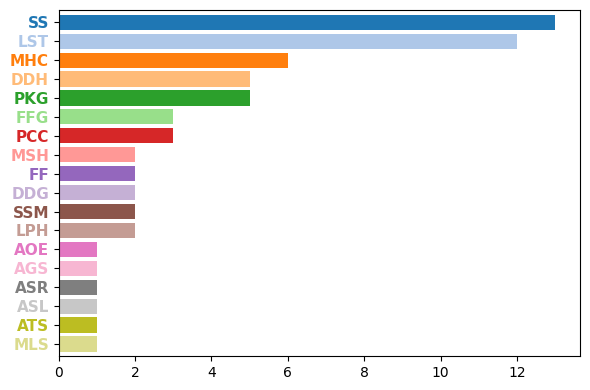

In [41]:
# 1) 데이터 준비 
shiptype_count_summary = ais.groupby('ShipType')['mmsi'].nunique().sort_values(ascending=False)

# 2) LLM 묘사를 위한 전처리
data_dict_shiptype = shiptype_count_summary.to_dict()
shiptype_data = json.dumps(data_dict_shiptype, ensure_ascii=False, indent=4)

#3) 데이터 Dashboard 시각화
plt.figure(figsize=(6, 4))
colors = plt.cm.tab20.colors

ax = shiptype_count_summary.plot(
    kind="barh",
    color=colors[:len(shiptype_count_summary)],
    width=0.8
) 

# Y 축 레이블 색상을 막대 색상과 일치시키기
tick_labels = ax.get_yticklabels()

for i, label in enumerate(tick_labels):
    label.set_color(colors[i])
    label.set_weight('bold')
    label.set_fontsize(11)

ax.invert_yaxis()
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [42]:
print(shiptype_data)

{
    "SS": 13,
    "LST": 12,
    "MHC": 6,
    "DDH": 5,
    "PKG": 5,
    "FFG": 3,
    "PCC": 3,
    "MSH": 2,
    "FF": 2,
    "DDG": 2,
    "SSM": 2,
    "LPH": 2,
    "AOE": 1,
    "AGS": 1,
    "ASR": 1,
    "ASL": 1,
    "ATS": 1,
    "MLS": 1
}


In [43]:
#####################################################
# 평균 Direction(향) 분석을 통한 지배적인 교통흐름 파악 #
#####################################################
def get_direction_analysis(df):
    # '이동' 중인 선박만 추출
    cruising_raw = df[df['status'] != '정박/대기'].copy()
    
    cruising = cruising_raw.groupby('mmsi').agg({
        'first_course': 'last',
        'avg_speed': 'mean'}).reset_index()
    
    if cruising.empty:
        return "현재 이동 중인 주요 선박 흐름 없음"

    # --- 1. 방향 그룹화 (Binning) ---
    # 0~360도를 8방위로 나누기 
    # 북쪽(North)은 337.5~22.5도 사이이므로, 계산 편의를 위해 범위 조절.
    bins = [-0.1, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360.1]
    labels = ['북', '북동', '동', '남동', '남', '남서', '서', '북서', '북'] 

    cruising['direction_group'] = pd.cut(cruising['first_course'], bins=bins, labels=labels, ordered=False)
    
    # --- 2. 통계 계산 ---
    # 각 방향별 선박 수 계산 및 0인 항목 제거
    flow_counts = cruising['direction_group'].value_counts()
    flow_counts = flow_counts[flow_counts > 0]

    unique_labels = []
    for l in labels:
        if l not in unique_labels:
            unique_labels.append(l)
    
    cruising['sin'] = np.sin(np.radians(cruising['first_course']))
    cruising['cos'] = np.cos(np.radians(cruising['first_course']))
    
    agg_flow = cruising.groupby('direction_group', observed=True).agg({
        'mmsi': 'count',
        'avg_speed': 'mean',
        'sin': 'mean',
        'cos': 'mean'
    })
    
    # 텍스 요약 생성
    flow_reports = []
    
    for direction in unique_labels: 
        if direction in agg_flow.index:
            data = agg_flow.loc[direction]
            count = int(data['mmsi'])
    
            if count == 0: continue
    
            curr_avg_speed = float(data['avg_speed'])
            vec_avg = float(np.degrees(np.arctan2(data['sin'], data['cos'])) % 360)
            
            flow_reports.append({
                "direction":f"{direction}진",
                "ship_count": count,
                "average_speed_knot": round(curr_avg_speed, 1),
                "vector_course_deg": round(vec_avg, 1)
            })
    return json.dumps(flow_reports, ensure_ascii=False, indent=4)


In [47]:
## 주요 향별 묘사를 위한 데이터 전처리##
# df_summarization 
def compress_ship_data_py(df):
    # 1. 데이터 타입 변환 및 정렬
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
    df['course'] = pd.to_numeric(df['course'])
    df['speed'] = pd.to_numeric(df['speed'])
    df = df.sort_values(['ShipName','timestamp'])

    # 2. 변화량 및 트리거 계산
    df['prev_lon'] = df.groupby('ShipName')['longitude'].shift(1).fillna(df['longitude'])
    df['prev_lat'] = df.groupby('ShipName')['latitude'].shift(1).fillna(df['latitude'])
    df['prev_course'] = df.groupby('ShipName')['course'].shift(1).fillna(df['course'])
    df['prev_speed'] = df.groupby('ShipName')['speed'].shift(1).fillna(df['speed'])

    # 1) 위치 변화 비교
    df['pos_change'] = np.where(
        (df['longitude'].round(3) != df['prev_lon'].round(3)) | 
        (df['latitude'].round(3) != df['prev_lat'].round(3)), 1, 0
    )

    # 2) 침로 변화 비교(180도 회전 보정 포함)
    df['course_diff_raw'] = df['course'] - df['prev_course']
    df['course_diff'] = np.where(df['course_diff_raw'] > 180, df['course_diff_raw'] - 360,
                        np.where(df['course_diff_raw'] < -180, df['course_diff_raw'] + 360,
                        df['course_diff_raw']))
    df['course_change'] = np.where((df['course_diff'].abs() >= 20) & (df['speed'] >= 1.0), 1, 0)

    # 3) 속도 변화
    df['speed_diff'] = df['speed'] - df['prev_speed']
    df['speed_change'] = np.where(df['speed_diff'].abs() >= 2, 1, 0)

    # 4) 이벤트 트리거 
    df['event_trigger'] = np.where((df['pos_change'] == 1) | (df['course_change'] == 1) | (df['speed_change'] == 1), 1, 0)
    df['group_id'] = df.groupby('ShipName')['event_trigger'].cumsum()

    # 5. 그룹별 요약
    df_summarized = df.groupby(['ShipName', 'group_id']).agg(
        mmsi = ('mmsi', 'first'),
        higher_types = ('higher_types', 'first'),
        radius = ('radius','first'),
        start_time = ('timestamp', 'min'),
        end_time = ('timestamp', 'max'),
        lon = ('longitude', 'first'),
        lat = ('latitude', 'first'),
        first_course = ('course', 'first'), 
        avg_speed = ('speed', 'mean'),
        turn_val = ('course_diff', 'first'),
        accel_val = ('speed_diff', 'first')
    ).reset_index()

    # 6. 그룹 간 속도 차이 및 최종 상태 판별
    df_summarized['prev_avg_speed'] = df_summarized.groupby('ShipName')['avg_speed'].shift(1).fillna(df_summarized['avg_speed'])
    df_summarized['group_speed_diff'] = df_summarized['avg_speed'] - df_summarized['prev_avg_speed']

    def determine_status(row):
        # 1순위: 정박/대기
        if row['avg_speed'] < 1.0:
            return "정박/대기"

        # 2순위: 운항 중 상세 상태 
        # 선회 판단
        turn_desc = ""
        if abs(row['turn_val']) >= 20 and row['avg_speed'] >= 1.0:
            direction = "우선회" if row['turn_val'] > 0 else "좌선회"
            turn_desc = f"{direction}({round(abs(row['turn_val']), 1)}°)"

        # 가감속 판단
        accel_desc = ""
        if row['group_speed_diff'] >= 2:
            accel_desc = "가속"
        elif row['group_speed_diff'] < -2:
            accel_desc = "감속"

        # 기본 이동 상태
        move_desc = "이동/통과" if row['avg_speed'] >= 5.0 else "저속 운항"

        # 정보 결합 (불필요한 공백 제거)
        status_parts = [turn_desc, accel_desc, move_desc]
        return " ".join([p for p in status_parts if p != ""]).strip()

    df_summarized['status'] = df_summarized.apply(determine_status, axis=1)

    # 불필요한 중간 계산 컬럼 삭제 후 반환
    return df_summarized.drop(columns=['prev_avg_speed'])

def compress_ship_data_py_further(df):
    df['prev_status'] = df.groupby('ShipName')['status'].shift(1).fillna(df['status'])
    # 1) status 변화 비교
    df['status_change'] = np.where(
        df['status'] != df['prev_status'], 1, 0
    )
    df['group_id'] = df.groupby('ShipName')['status_change'].cumsum()
    df_summarized = df.groupby(['ShipName', 'group_id']).agg(
        mmsi = ('mmsi', 'first'),
        higher_types = ('higher_types', 'first'),
        radius = ('radius','first'),
        start_time = ('start_time', 'min'),
        end_time = ('end_time', 'max'),
        lon = ('lon', 'first'),
        lat = ('lat', 'first'),
        first_course = ('first_course', 'first'), 
        avg_speed = ('avg_speed', 'mean'),
        turn_val = ('turn_val', 'first'),
        accel_val = ('accel_val', 'first'),
        status = ('status', 'first')
    ).reset_index()
    return df_summarized

In [45]:
status_sum = compress_ship_data_py(ais)
status_sum_further = compress_ship_data_py_further(status_sum)
print(f"status_sum has {status_sum.shape} & status_sum_further has {status_sum_further.shape}")

status_sum has (6965, 17) & status_sum_further has (1152, 14)


In [46]:
direction_flow_data = get_direction_analysis(status_sum_further)
print(direction_flow_data)

[
    {
        "direction": "북진",
        "ship_count": 3,
        "average_speed_knot": 10.3,
        "vector_course_deg": 5.8
    },
    {
        "direction": "북동진",
        "ship_count": 10,
        "average_speed_knot": 9.0,
        "vector_course_deg": 46.7
    },
    {
        "direction": "동진",
        "ship_count": 7,
        "average_speed_knot": 10.8,
        "vector_course_deg": 88.7
    },
    {
        "direction": "남동진",
        "ship_count": 5,
        "average_speed_knot": 8.1,
        "vector_course_deg": 140.1
    },
    {
        "direction": "남진",
        "ship_count": 2,
        "average_speed_knot": 10.6,
        "vector_course_deg": 186.2
    },
    {
        "direction": "남서진",
        "ship_count": 13,
        "average_speed_knot": 9.8,
        "vector_course_deg": 228.0
    },
    {
        "direction": "서진",
        "ship_count": 8,
        "average_speed_knot": 7.0,
        "vector_course_deg": 265.8
    },
    {
        "direction": "북서진",
        "ship_c

In [19]:
############################################################
### 주요 항만(부산, 울산, 광양, 목포)별 선박 입출항 현황 묘사 ###
############################################################

In [48]:
import holoviews as hv
import geopandas as gpd

# 주요 항만 데이터
ports_gdf = gpd.read_file('./data/gis_data/major_ports.shp')
ports_gdf = ports_gdf.to_crs("EPSG:4326")

# 항만 입출항 판정 함수: 출항 선박은 반드시 해당 항구에서 출발하여, 항구 경계선 밖으로 나가야만 출항으로 판정
# 입항 선박은 항구 경계선 밖에서 시작하여 항구경계 안으로로 들어오 것만 인정
def is_leaving(traj, poly):
    #시작은 안에서, 끝은 밖에서
     return traj.get_start_location().intersects(poly) and not traj.get_end_location().intersects(poly)

def is_entering(traj, poly):
    #시작은 안에서, 끝은 밖에서
     return not traj.get_start_location().intersects(poly) and  traj.get_end_location().intersects(poly)

# 정박/대기 판정을 위한 데이터 전처리
stop_temp_df = compress_ship_data_py(ais)
stop_temp_df = compress_ship_data_py_further(stop_temp_df)

latest_indices = stop_temp_df.groupby('mmsi')['end_time'].idxmax()
latest_status_df = stop_temp_df.loc[latest_indices]
anchored_ships = latest_status_df[latest_status_df['status'] == '정박/대기']

geometry = gpd.points_from_xy(anchored_ships['lon'], anchored_ships['lat'])
anchored_ships_gdf = gpd.GeoDataFrame(anchored_ships, geometry=geometry, crs="EPSG:4326")

In [49]:
## 주요 항만별 입출항 현황 시각화 for Geospatial DASHBOARD ## 

# 1. 대상 항구 리스트
target_ports = ['BUSAN HANG', 'ULSAN HANG','GWANGYANG HANG, HADONG HANG', 'MOKPO HANG']
port_plots = []

for port_name in target_ports:
    # --- A. 해당 항구 폴리곤 및 영역(AOI) 추출 ---
    single_port_gdf = ports_gdf[ports_gdf['objnam'] == port_name]
    if single_port_gdf.empty: continue
    
    # 500m 버퍼 적용 (입출항 판정)
    port_projected = single_port_gdf.to_crs(epsg=5179)
    port_projected['geometry'] = port_projected.geometry.buffer(500)
    port_aoi = port_projected.to_crs(epsg=4326).geometry.iloc[0]

    # --- B. 해당 항구 범위 계산 (줌인용) ---
    bounds = single_port_gdf.geometry.total_bounds
    margin = 0.05  # 개별 항구 줌인이므로 마진을 작게 설정
    p_xlim = (bounds[0] - margin, bounds[2] + margin)
    p_ylim = (bounds[1] - margin, bounds[3] + margin)

    # --- C. 해당 항구 전용 데이터 필터링 ---
    # 출발/도착 항적 필터링
    p_departures = [t for t in trips if is_leaving(t, port_aoi)]
    p_arrivals = [t for t in trips if is_entering(t, port_aoi)]
    
    # 정박 선박 필터링 (해당 항구 폴리곤 안에 있는 것만)
    p_anchored = anchored_ships_gdf[anchored_ships_gdf.geometry.within(port_aoi)]

    # --- D. 개별 항구 레이어 생성 ---
    layers = []
    
    # 1. 배경 지도 및 항구 폴리곤 (가장 아래)
    layers.append(single_port_gdf.hvplot(
        title=f"{port_name} 현황", color='red', alpha=0.2, geo=True,
        tiles='OSM', xlim=p_xlim, ylim=p_ylim, 
        frame_width=350, frame_height=350 # 여러 개를 놓기 위해 크기 조절
    ))
    
    # 2. 출발 항적
    if p_departures:
        layers.append(mpd.TrajectoryCollection(p_departures).hvplot(color="blue", label="출발", line_width=2))
    
    # 3. 도착 항적
    if p_arrivals:
        layers.append(mpd.TrajectoryCollection(p_arrivals).hvplot(color="orange", label="도착", line_width=2))
    
    # 4. 정박 포인트
    if not p_anchored.empty:
        layers.append(p_anchored.hvplot.points(color='red', label="정박/대기", geo=True, size=5))

    # --- E. 항구별 오버레이 합체 후 리스트에 저장 ---
    port_plots.append(hv.Overlay(layers).opts(show_legend=(port_name == target_ports[0])))

# 2. 모든 항구 지도를 격자 형태로 배치
# .cols(2)는 한 줄에 2개씩 배치하겠다는 뜻입니다.
final_layout = hv.Layout(port_plots).cols(2)
final_plot = final_layout.opts(shared_axes=False) # 각 지도가 독립적인 범위를 갖도록 설정

final_plot

:Layout
   .Overlay.I   :Overlay
      .WMTS.I            :WMTS   [Longitude,Latitude]
      .Polygons.I        :Polygons   [Longitude,Latitude]
      .WMTS.II           :WMTS   [Longitude,Latitude]
      .Path.출발.I         :Path   [Longitude,Latitude]
      .Path.출발.II        :Path   [Longitude,Latitude]
      .Path.출발.III       :Path   [Longitude,Latitude]
      .Path.출발.IV        :Path   [Longitude,Latitude]
      .Path.출발.V         :Path   [Longitude,Latitude]
      .Points.출발.I       :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.출발.II      :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.출발.III     :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.출발.IV      :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.출발.V       :Points   [Longitude,Latitude]   (triangle_angle)
      .WMTS.III          :WMTS   [Longitude,Latitude]
      .Path.도착.I         :Path   [Longitude,Latitude]
      .Path.도착.II        :Path   [Longitude,Latitude]
      .Points.도착.I       :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.도착.II      :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.정박_over_대기 :Points   [Longitude,Latitude]
   .Overlay.II  :Overlay
      .WMTS.I            :WMTS   [Longitude,Latitude]
      .Polygons.I        :Polygons   [Longitude,Latitude]
      .WMTS.II           :WMTS   [Longitude,Latitude]
      .Path.출발           :Path   [Longitude,Latitude]
      .Points.출발         :Points   [Longitude,Latitude]   (triangle_angle)
      .WMTS.III          :WMTS   [Longitude,Latitude]
      .Path.도착.I         :Path   [Longitude,Latitude]
      .Path.도착.II        :Path   [Longitude,Latitude]
      .Points.도착.I       :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.도착.II      :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.정박_over_대기 :Points   [Longitude,Latitude]
   .Overlay.III :Overlay
      .WMTS.I            :WMTS   [Longitude,Latitude]
      .Polygons.I        :Polygons   [Longitude,Latitude]
      .WMTS.II           :WMTS   [Longitude,Latitude]
      .Path.도착.I         :Path   [Longitude,Latitude]
      .Path.도착.II        :Path   [Longitude,Latitude]
      .Path.도착.III       :Path   [Longitude,Latitude]
      .Path.도착.IV        :Path   [Longitude,Latitude]
      .Points.도착.I       :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.도착.II      :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.도착.III     :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.도착.IV      :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.정박_over_대기 :Points   [Longitude,Latitude]
   .Overlay.IV  :Overlay
      .WMTS.I            :WMTS   [Longitude,Latitude]
      .Polygons.I        :Polygons   [Longitude,Latitude]
      .WMTS.II           :WMTS   [Longitude,Latitude]
      .Path.출발           :Path   [Longitude,Latitude]
      .Points.출발         :Points   [Longitude,Latitude]   (triangle_angle)
      .WMTS.III          :WMTS   [Longitude,Latitude]
      .Path.도착.I         :Path   [Longitude,Latitude]
      .Path.도착.II        :Path   [Longitude,Latitude]
      .Points.도착.I       :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.도착.II      :Points   [Longitude,Latitude]   (triangle_angle)
      .Points.정박_over_대기 :Points   [Longitude,Latitude]

In [50]:
#####################################
### 데이터 검증을 위한 temp 리포트 생성


# 분석할 항구 리스트 (시각화와 동일하게 설정)
target_ports = ['BUSAN HANG', 'ULSAN HANG', 'GWANGYANG HANG, HADONG HANG', 'MOKPO HANG']

print("="*60)
print(f"항만별 선박 입출항 및 정박 현황 리포트 ({start_time} ~ {end_time})")
print("="*60)

for port_name in target_ports:
    # 1. 해당 항구 폴리곤 추출 및 버퍼 설정
    single_port_gdf = ports_gdf[ports_gdf['objnam'] == port_name]
    if single_port_gdf.empty:
        continue
    
    # 입출항 판정용 버퍼(500m)
    port_projected = single_port_gdf.to_crs(epsg=5179)
    port_projected['geometry'] = port_projected.geometry.buffer(500)
    port_aoi = port_projected.to_crs(epsg=4326).geometry.iloc[0]

    # 2. 해당 항구 데이터 필터링
    # 출발/도착 항적
    p_departures = [t for t in trips if is_leaving(t, port_aoi)]
    p_arrivals = [t for t in trips if is_entering(t, port_aoi)]
    
    # 정박 선박 (전체 정박 데이터 중 해당 항구 폴리곤 내 위치한 것)
    p_anchored = anchored_ships_gdf[anchored_ships_gdf.geometry.within(port_aoi)]

    # 3. 리포트 출력
    print(f"\n[ {port_name} 분석 결과 ]")
    print("-" * 30)
    
    # A. 정박 현황
    print(f"▶ 정박/대기 중인 선박: 총 {len(p_anchored)}척")
    if not p_anchored.empty:
        for _, row in p_anchored.iterrows():
            print(f"   - {row['ShipName']} ({row['mmsi']}): {row['start_time'].strftime('%Y-%m-%d %H:%M:%S')}부터 정박 중")
    else:
        print("   - 현재 정박 중인 선박 없음")

    # B. 출발 현황
    print(f"▶ 출발/기동 선박: 총 {len(p_departures)}척")
    for traj in p_departures:
        st = traj.get_start_time()
        name = traj.df['ShipName'].iloc[0]
        stype = traj.df['ShipType'].iloc[0]
        print(f"   - {stype} '{name}': {st} 에 출발")

    # C. 도착 현황
    print(f"▶ 도착/진입 선박: 총 {len(p_arrivals)}척")
    for traj in p_arrivals:
        et = traj.get_end_time()
        name = traj.df['ShipName'].iloc[0]
        stype = traj.df['ShipType'].iloc[0]
        print(f"   - {stype} '{name}': {et} 에 도착")
    
    print("-" * 30)

print("\n리포트 생성이 완료되었습니다.")

항만별 선박 입출항 및 정박 현황 리포트 (2022-12-01 00:00:00 ~ 2022-12-02 12:00:00)

[ BUSAN HANG 분석 결과 ]
------------------------------
▶ 정박/대기 중인 선박: 총 4척
   - PKG-722 임병래 (273331810): 2022-12-01 00:00:06부터 정박 중
   - MHC-565 김포 (352403000): 2022-12-01 00:04:18부터 정박 중
   - MHC-563 고령 (477024700): 2022-12-01 00:01:07부터 정박 중
   - MHC-567 금화 (667002156): 2022-12-01 00:01:24부터 정박 중
▶ 출발/기동 선박: 총 5척
   - ATS 'ATS- 평택': 2022-12-01 12:12:05 에 출발
   - LST 'LST-681 고준봉': 2022-12-01 12:02:02 에 출발
   - LST 'LST-672 덕봉': 2022-12-01 08:45:40 에 출발
   - PKG 'PKG-718 현시학': 2022-12-01 23:10:38 에 출발
   - LST 'LST-673 비봉': 2022-12-01 09:55:04 에 출발
▶ 도착/진입 선박: 총 2척
   - ATS 'ATS- 평택': 2022-12-01 08:48:05 에 도착
   - SS 'SS-061 장보고': 2022-12-02 11:55:04 에 도착
------------------------------

[ ULSAN HANG 분석 결과 ]
------------------------------
▶ 정박/대기 중인 선박: 총 2척
   - LST-682 비로봉 (372024000): 2022-12-01 16:49:21부터 정박 중
   - DDH-973 양만춘 (538008114): 2022-12-01 07:47:32부터 정박 중
▶ 출발/기동 선박: 총 1척
   - SS 'SS-062 이천': 2022-12-01 00:

In [51]:
########################################
### LLM전달을 위한 분석결과 데이터 json출력

import json
from datetime import datetime

# 결과를 담을 메인 딕셔너리
report_data = {
    "report_info": {
        "analysis_period": {
            "start": str(start_time),
            "end": str(end_time)
        },
        "generated_at": datetime.now().isoformat(),
        "target_ports": target_ports
    },
    "ports_analysis": []
}

for port_name in target_ports:
    # 1. 데이터 필터링 (기존 로직 동일)
    single_port_gdf = ports_gdf[ports_gdf['objnam'] == port_name]
    if single_port_gdf.empty: continue
    
    port_projected = single_port_gdf.to_crs(epsg=5179)
    port_projected['geometry'] = port_projected.geometry.buffer(500)
    port_aoi = port_projected.to_crs(epsg=4326).geometry.iloc[0]

    p_departures = [t for t in trips if is_leaving(t, port_aoi)]
    p_arrivals = [t for t in trips if is_entering(t, port_aoi)]
    p_anchored = anchored_ships_gdf[anchored_ships_gdf.geometry.within(port_aoi)]

    # 2. 항구별 JSON 구조 생성
    port_entry = {
        "port_name": port_name,
        "summary": {
            "anchored_count": len(p_anchored),
            "departure_count": len(p_departures),
            "arrival_count": len(p_arrivals)
        },
        "details": {
            "anchored_ships": [
                {
                    "name": row['ShipName'],
                    "mmsi": int(row['mmsi']),
                    "anchored_since": str(row['start_time'].strftime('%Y-%m-%d %H:%M:%S'))
                } for _, row in p_anchored.iterrows()
            ],
            "departures": [
                {
                    "name": t.df['ShipName'].iloc[0],
                    "type": t.df['ShipType'].iloc[0],
                    "mmsi": int(t.id),
                    "event_time": str(t.get_start_time())
                } for t in p_departures
            ],
            "arrivals": [
                {
                    "name": t.df['ShipName'].iloc[0],
                    "type": t.df['ShipType'].iloc[0],
                    "mmsi": int(t.id),
                    "event_time": str(t.get_end_time())
                } for t in p_arrivals
            ]
        }
    }
    report_data["ports_analysis"].append(port_entry)

# 3. JSON 출력 및 저장
major_ports_sum = json.dumps(report_data, indent=4, ensure_ascii=False)

print(major_ports_sum) # 화면 출력

# 필요한 경우 파일로 저장
# with open('port_analysis_report.json', 'w', encoding='utf-8') as f:
#     f.write(json_output)

{
    "report_info": {
        "analysis_period": {
            "start": "2022-12-01 00:00:00",
            "end": "2022-12-02 12:00:00"
        },
        "generated_at": "2026-04-14T16:59:22.273939",
        "target_ports": [
            "BUSAN HANG",
            "ULSAN HANG",
            "GWANGYANG HANG, HADONG HANG",
            "MOKPO HANG"
        ]
    },
    "ports_analysis": [
        {
            "port_name": "BUSAN HANG",
            "summary": {
                "anchored_count": 4,
                "departure_count": 5,
                "arrival_count": 2
            },
            "details": {
                "anchored_ships": [
                    {
                        "name": "PKG-722 임병래",
                        "mmsi": 273331810,
                        "anchored_since": "2022-12-01 00:00:06"
                    },
                    {
                        "name": "MHC-565 김포",
                        "mmsi": 352403000,
                        "anchored_since":

In [56]:
######################
### 상태별 선박 묘사 ###
######################

# 현재시점 기준 이동/통과, 저속 운항, 정박/대기 함정 추출 

def ship_status_extraction(df, end_time): #df = 추출된 선박
    df = compress_ship_data_py(df)
    df = compress_ship_data_py_further(df)
    end_time = pd.to_datetime(end_time, utc=True) #현재 필터링 기준 시간
    df['end_time'] = pd.to_datetime(df['end_time'], utc=True)
    df = df.sort_values(['ShipName','mmsi'])
    df = df.groupby('ShipName').tail(1)

    #이동 통과 filtering
    moving_condition = (
        ((end_time - df['end_time']) <= pd.Timedelta(hours=1)) &
        (df['status'].str.contains("이동/통과"))
    )

    #정박/대기  filtering
    stop_condition = (
        ((end_time - df['end_time']) <= pd.Timedelta(hours=1)) &
        (df['status'].str.contains("정박/대기"))
    )

    #저속운항 filtering 
    slow_moving_condition = (
        ((end_time - df['end_time']) <= pd.Timedelta(hours=1)) &
        (df['status'].str.contains("저속 운항"))
    )

    #이동/통과 중인 선박 리스트 추출 및 json변환
    moving_df = df[moving_condition]
    moving_ships = moving_df[['ShipName','mmsi','status']].drop_duplicates().to_dict(orient='records')
    moving_ships_json = json.dumps(moving_ships, ensure_ascii=False, indent=4)

    #정박/대기 중인 선박 리스트 추출 및 json변환
    stop_df = df[stop_condition]
    stop_ships = stop_df[['ShipName','mmsi','status']].drop_duplicates().to_dict(orient='records')
    stop_ships_json = json.dumps(stop_ships, ensure_ascii=False, indent=4)

    #정박/대기 중인 선박 리스트 추출 및 json변환
    slow_df = df[slow_moving_condition]
    slow_ships = slow_df[['ShipName','mmsi','status']].drop_duplicates().to_dict(orient='records')
    slow_ships_json = json.dumps(slow_ships, ensure_ascii=False, indent=4)
    
    return moving_ships_json, stop_ships_json, slow_ships_json

    #현재 이동 중인 선박 리스트 추출


moving_result, stopping_result, slow_result = ship_status_extraction(ais, end_time)

print(moving_result)
print("="*55)
print(stopping_result)
print("="*55)
print(slow_result)


[
    {
        "ShipName": "ASR-21 청해진",
        "mmsi": 538007238,
        "status": "이동/통과"
    },
    {
        "ShipName": "DDG-992 율곡이이",
        "mmsi": 431400833,
        "status": "이동/통과"
    },
    {
        "ShipName": "DDH-971 광개토대왕",
        "mmsi": 305089000,
        "status": "이동/통과"
    },
    {
        "ShipName": "DDH-972 을지문덕",
        "mmsi": 538002403,
        "status": "이동/통과"
    },
    {
        "ShipName": "FF-961 청주",
        "mmsi": 538009442,
        "status": "이동/통과"
    },
    {
        "ShipName": "LST-676 위봉",
        "mmsi": 273358000,
        "status": "이동/통과"
    },
    {
        "ShipName": "LST-686 천왕봉",
        "mmsi": 351225000,
        "status": "이동/통과"
    },
    {
        "ShipName": "MHC-562 강진",
        "mmsi": 538005766,
        "status": "이동/통과"
    },
    {
        "ShipName": "MHC-566 고창",
        "mmsi": 538007592,
        "status": "이동/통과"
    },
    {
        "ShipName": "MLS-560 원산함",
        "mmsi": 636021418,
        "status": "이동/통

In [55]:
##############################
## 특이 기동 선박 분석 및 추출 ##
##############################
# mmsi같이 출력

### 선회 또는 속도변화가 빈번했던 선박 리스트 추출

def unusual_ships_extraction(df):
    df = status_sum_further
    df = compress_ship_data_py_further(df)

    # 1) 분석 키워드 정의
    turn_keywords = ['우선회', '좌선회']
    speed_keywords = ['가속', '감속']

    # 2) 각 행별로 특이 기동여부 체크
    df['is_turning'] = df['status'].str.contains('|'.join(turn_keywords))
    df['is_speed_changing'] = df['status'].str.contains('|'.join(speed_keywords))

    # 3) ShipName별로 그룹화하여 특이 기동 횟수 집계
    behavior_summary = df.groupby('ShipName').agg(
        turn_count = ('is_turning', 'sum'),
        speed_change_count = ('is_speed_changing', 'sum'),
        total_records = ('status', 'count'),
        status_list=('status', lambda x: list(x.unique()))
    ).reset_index()

    unusual_ships_df = behavior_summary[
        (behavior_summary['turn_count'] >= 4) | 
        (behavior_summary['speed_change_count'] >= 4)
        ].sort_values(by='turn_count', ascending=False)

    unusual_ships_json = unusual_ships_df[['ShipName', 'turn_count', 'speed_change_count', 'status_list']].to_dict(orient='records')
    unusual_final_report_json = json.dumps(unusual_ships_json, ensure_ascii=False, indent=4)
    
    return unusual_final_report_json


unusual_behavior = unusual_ships_extraction(ais)
print(unusual_behavior)

[
    {
        "ShipName": "FF-959 부산",
        "turn_count": 76,
        "speed_change_count": 11,
        "status_list": [
            "이동/통과",
            "좌선회(30.2°) 이동/통과",
            "가속 이동/통과",
            "감속 이동/통과",
            "좌선회(23.4°) 이동/통과",
            "좌선회(99.8°) 가속 이동/통과",
            "좌선회(23.7°) 이동/통과",
            "좌선회(24.7°) 이동/통과",
            "감속 저속 운항",
            "우선회(27.5°) 저속 운항",
            "좌선회(33.0°) 저속 운항",
            "정박/대기",
            "우선회(86.2°) 저속 운항",
            "좌선회(39.4°) 저속 운항",
            "우선회(173.4°) 저속 운항",
            "좌선회(162.6°) 저속 운항",
            "저속 운항",
            "좌선회(55.1°) 저속 운항",
            "좌선회(149.4°) 저속 운항",
            "좌선회(32.2°) 저속 운항",
            "좌선회(176.9°) 저속 운항",
            "좌선회(133.9°) 저속 운항",
            "좌선회(175.1°) 저속 운항",
            "좌선회(129.1°) 저속 운항",
            "우선회(20.2°) 저속 운항",
            "우선회(58.1°) 저속 운항",
            "우선회(40.5°) 저속 운항",
            "우선회(75.5°) 저속 운항",
            "우선회(64.6°) 저

In [30]:
############################
### LLM을 활용한 답변 통합 ###
############################

#####################################
### "LOCAL" VLLM MODEL Initiation ###
#####################################
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

#vllm starter 
vllm = ChatOpenAI(
    api_key = "ai",
    base_url = "http://192.168.0.110:8000/v1", # for A6000
    # base_url = "http://192.168.0.108:8000/v1", # for A5000
    model = "openai/gpt-oss-20b",
    # model = "unsloth/Meta-Llama-3.1-70B-Instruct-bnb-4bit"
    # model = "unsloth/gemma-3-27b-it-bnb-4bit",
    # model="meta-llama/Llama-3.1-8B-Instruct",
    # model="mistralai/Mistral-7B-Instruct-v0.3",
    # model="Qwen/Qwen2-7B-Instruct",
    # model="unsloth/Mistral-Small-24B-Instruct-2501-bnb-4bit",
    # model = "unsloth/Qwen3-14B-bnb-4bit",
    # model = "unsloth/gemma-3-12b-it-bnb-4bit",
    # model = "unsloth/gemma-2-9b-it-bnb-4bit",
    max_tokens = 6000,
    temperature = 0.2
)

In [31]:
# 전체패턴 요약을 위한 프롬프트 템플릿
def prompt_template_trajs_overall(start_time, end_time, time_diff,
                                  clusters_data, speed_data,
                                  direction_flow_data,
                                  trajs_flow_data, shiptype_data, major_ports_sum, 
                                  moving_result, stopping_result, slow_result, 
                                  unusual_behavior):
    return f"""
    # Role
    당신은 대한민국 해양수산부 소속의 '해상교통관제(VTS) 데이터 분석 전문가' 입니다.
    제공된 통계 데이터를 바탕으로 해상 교통 흐름의 전체적인 패턴을 분석하고 현재 선박 운항 현황을 묘사해 주세요.  

    #Input Data (Summarized Statistics)
    1. [분석 대상 시간]:
    - 시작 시점: {start_time}
    - 종료 시점: {end_time}
    - (약 {time_diff} 동안의 데이터 집계 결과)
    2. [구역별 밀집 현황]: 
    {clusters_data}
    3. [구역별 선박 이동 속도 요약]:
    {speed_data}
    4. [주요 교통 흐름 (방향별 이동 현황)]:
    {direction_flow_data}
    5. [구역 간 주요 유동성(OD Flow) 현황]: 
    {trajs_flow_data}
    6. [선박 유형별 요약]:
    {shiptype_data}
    7. [주요 항만별 선박 입출항 현황]:
    {major_ports_sum}
    8. [현재 선박 상태 요약]:
    - 순항 중인 선박 리스트: {moving_result}  
    - 정박/대기 중인 선박 리스트: {stopping_result}
    - 저속 운항 중인 선박 리스트: {slow_result}
 
    9. [주요 선박 특이 기동 데이터]:
    {unusual_behavior}
    
    # Context & Rules
    - cluster_data에서 'total_stay_index'가 높을수록 해당 구역에 더 많은 항적이 밀집되어 있음을 의미합니다. 
    - speed_data에서 'mean'은 해상구역별 평균속도를 의미합니다. 평균속도가 클수록 선박이 해당 구간에서 더 빨리 이동하고 있음을 의미합니다. 
    - traj_flow_data에서 'weight'가 높을수록 해당 경로(origin_zone -> dest_zone)는 주 간선 항로(Main Route)임을 의미합니다.
    - 선박 유형별로 사용자가 쉽게 알아볼 수 있도록 테이블로 정리해줘. 데이터에 근거하여 가장 높은 비중을 차지하는 상위 3개 함종이 무엇인지 간단하게 설명해주고 상상이나 추측성 발언은 완전히 삼가해줘.  
    - 보고서에는 traj_stay_index 값 혹은 weight값을 포함시키지 않아도 되. 이 값이 높다는건 항적이나 항로가 많이 밀집되어 있다는 의미정도로만 해석하면되.  
    - 전문가적 통찰은 포함하되, 모든 분석은 반드시 제공된 데이터의 수치에 근거해야 합니다. 

    # Mission
    1. **[분석 대상 시간]**: 1번 데이터를 활용하여 분석 대상 시간을 자연스러운 자연어로 묘사하세요. 
    2. **[밀집 구역 분석(Data Dashboard Fig 1 참고)]**: 2번 데이터를 활용하여 'total_stay_index'를 기준으로 상위 3개 핵심 해역을 선정하고, 해당 지역이 해상 교통 안전 관리 측면에서 왜 중요한지 한 문장으로 요약하세요.  
    3. **[구간별 속도 분석(Data Dashboard Fig 1 참고)]**: 2번 데이터를 활용하여 각 구역(Zone)별 선박의 평균 속도(mean) 분포를 비교하고, 대한민국 남해안 해역의 공간적 특성에 따른 속도 변화 패턴을 분석하세요. 
         특히 연안과 외해, 그리고 주요 항만 주변 간의 전반적인 주요 핵심 패턴만 설명하세요.   
    4. **[이동 방향 및 흐름 분석]**: 4번 데이터를 바탕으로 현재 가장 지배적인 이동 방향을 식별하고, 해당 흐름의 규모 및 이동 속도의 특성을 분석하세요.  
    5. **[주요 항로 패턴(Data Dashboard Fig 1 참고)]**: 5번 데이터를 활용하여 'weight' 기준 상위 5개 항로를 분석하여 대한민국 남해안의 주요 항로 패턴이 어떻게 형성되어 있는지 설명하세요. 
    6. **[선박 유형 요약(Data Dashboard Table 1 참고)]**: 2번 데이터를 활용하여 선박 유형별 카운트 테이블에 대해 간단하게 설명하세요.  
    
    7. **[주요 항만별 선박 입출항 현황(Data Dashboard Fig 2 참고)]**: 7번 데이터를 활용하여 주요 항만별 선박 입출항 현황을 다음 예시와 같이 자세하게 기술해주세요. 
    예시 1:
    ▶ 정박/대기 중인 선박: 총 4척
   - PKG-722 임병래 (273331810): 2022-12-01 00:00:06부터 정박 중
   - MHC-565 김포 (352403000): 2022-12-01 00:04:18부터 정박 중
   - MHC-563 고령 (477024700): 2022-12-01 00:01:07부터 정박 중
   - MHC-567 금화 (667002156): 2022-12-01 00:01:24부터 정박 중
    ▶ 출발/기동 선박: 총 5척
   - ATS 'ATS- 평택': 2022-12-01 12:06:01 에 출발
   - LST 'LST-681 고준봉': 2022-12-01 12:22:20 에 출발
   - LST 'LST-672 덕봉': 2022-12-01 08:20:09 에 출발
   - PKG 'PKG-718 현시학': 2022-12-01 23:00:47 에 출발
   - LST 'LST-673 비봉': 2022-12-01 09:58:31 에 출발
    ▶ 도착/진입 선박: 총 2척
   - ATS 'ATS- 평택': 2022-12-01 08:54:02 에 도착
   - SS 'SS-061 장보고': 2022-12-02 11:55:04 에 도착
    위 예시의 "부터 정박 중", " 에 출발", " 에 도착"이라는 조사와 서술어를 하나도 빠짐없이 포함해서 답변해줘.  
    
    8. **[현재 선박 상태 요약]**: 
    - 아래 예제와 같이 각 카테고리 별로 'ShipName', 'mmsi' 리스트만 정리해줘. 
    ▶ 순항 중인 선박 리스트
    - AST-688 일천봉(256011000)
    - DDG-992 율곡이이(431400833)
    ▶ 정박 중인 선박 리스트
    - AST-688 일천봉(256011000)
    - DDG-992 율곡이이(431400833)
    ▶ 저속 운항 중인 선박 리스트
    - AST-688 일천봉(256011000)
    - DDG-992 율곡이이(431400833)

    9. **[주요 선박 특이 기동 상세 분석 (New)]**: 
    - 제공된 9번 데이터 'unusual_bahavior'를 바탕으로 관제 데이터 분석 전문가의 관점에서 서술해줘.
    - 특히 좌선회 및 우선회등 선회가 빈번하거나 가속 감속 등 속도 변화가 잦은 선박을 우선적으로 기술해줘. 
    - 다음 제공된 예시와 같이 작성해줘. 
    ▶ 특이 기동 식별 보고
   - [선박명]: 'turn_count'회의 변침과 'speed_change_count'회의 속도 변화 포착.
   - 분석 내용: 'status_list'의 상태를 인용하여 기동의 특이점 간략하게 요약

    10. **[종합 결론]**:  현재 데이터상에서 나타나는 가장 두드러진 해상 교통 특징을 기술하세요. 

    # Tone & Manner
    - 간결하게 핵심 내용 요약.
    - 전문 용어(병목 구간, 간선 항로, 트래픽 밀도 등)를 적절히 활용.
    """

In [32]:
# Local LLM call 함수
def execute_llm_prompt(model, prompt_input):
    # LangChain's chat models take a list of message objects
    prompt_response = model.invoke(
        [
            HumanMessage(content=prompt_input)
        ],
        temperature = 0.1
    )
    # the following if statement is for preprocessing answers from QWEN since it contains <think> section by defulat. 
    if "<think>" in prompt_response.content:
        prompt_response = removing_think_from_qwen(prompt_response)
        return prompt_response

    else:
        return prompt_response.content

In [33]:
############################
##LLM을 통한 통합 답변 생성 ##

major_trajs_desc = prompt_template_trajs_overall(start_time, end_time, time_diff, 
                                                 clusters_data, speed_data,
                                                 direction_flow_data,
                                                 trajs_flow_data, shiptype_data, 
                                                 major_ports_sum,
                                                 moving_result, stopping_result, slow_result, 
                                                 unusual_behavior)

answer_major_trajs_desc = execute_llm_prompt(vllm, major_trajs_desc)

print(answer_major_trajs_desc)

**해상교통관제(VTS) 데이터 분석 보고서**  
*분석 기간: 2022‑12‑01 00:00:00 ~ 2022‑12‑02 12:00:00*  

---

### 1. 분석 대상 시간  
2022년 12월 1일 자정부터 12월 2일 정오까지 총 1일 12시간 동안의 선박 동태를 집계했습니다.  

---

### 2. 밀집 구역 분석 (Data Dashboard Fig 1)  
| 순위 | 구역 | 총 체류 지수 | 해상 교통 안전 관점에서의 중요성 |
|------|------|-------------|--------------------------------|
| 1 | 여수‑통영 외해 | 86 | 항적이 가장 집중돼 있어 항만 접근 시 충돌 위험이 높음 |
| 2 | 부산‑가덕 해역 | 84 | 부산항과 가덕항 사이의 교통량이 많아 항만 운영에 큰 영향 |
| 3 | 시모노세키‑기타큐슈 해역 | 54 | 일본과의 국제 항로가 교차해 국제선 통제 필요 |

---

### 3. 구간별 속도 분석 (Data Dashboard Fig 1)  
- **연안(내륙 근접)**  
  - 부산‑가덕 해역: 평균 1.18 kn  
  - 광양‑여수 해역: 평균 1.88 kn  
  - 대마도 남서 해역: 평균 3.81 kn  
  연안에서는 선박이 항만 접근·출입 시 속도가 낮아 정박·대기와 연계된 교통이 많음.  

- **외해(해상 개방)**  
  - 서남해 외해: 평균 16.05 kn  
  - 원거리 국제공해: 평균 9.90 kn  
  - 거제‑가덕 외해: 평균 5.16 kn  
  외해에서는 평균 속도가 높아 선박이 빠르게 이동하지만, 거제‑가덕 외해는 상대적으로 느려 항만 접근 전환점으로 작용.  

- **항만 주변**  
  - 부산‑대마도 입구 해역: 평균 12.43 kn  
  - 제주 남동부 해역: 평균 6.64 kn  
  항만 주변에서는 평균 속도가 중간 수준으로, 선박이 항만 접근·출입을 위해 속도를 조절함을 시사.  

---

### 

In [ ]:
# 전체적인 템플릿 통합방안. 
# 0) 해당 리포팅 날짜 및 시간 (Done)
# 1) 속도 묘사 통합 (히스토 그램 통합 방안, 구간 별 요약 방안)(Done)
# 2) Higher Types별 묘사 방안 (Done)
# 3) 주요 향(direction)별 이동 패턴 묘사 (Done)
# 4) status별 선박 묘사 (Done)
# 5) 주요 항만 별 요약(부산항, 울산항, 광양항, 목포항) (Done)
### 프롬프트 최적화!(Next) --> 테스트 --> 논문에 나와있는 single trajectory에 대한 여러 질문들 답별할 수 있도록 고도화(쿼리 라우팅) --> 통합
# 6) (창수)날씨 template
# 7) (창수)기존 템플릿과 통합

# 8) if enough time, 주요 지형/지물 묘사 방안(need research)

In [ ]:
##########################
### 데이터 검증 TESTING ###
##########################


#LLM을 통한 답변 생성
major_trajs_desc = prompt_template_trajs_overall(start_time, end_time, time_diff, 
                                                 clusters_data, speed_data,
                                                 direction_flow_data,
                                                 trajs_flow_data, shiptype_data)

answer_major_trajs_desc = execute_llm_prompt(vllm, major_trajs_desc)

print(answer_major_trajs_desc)

In [233]:
# print(trajs_flow_data)

In [57]:
analyst_prompt = ChatPromptTemplate.from_template("""
당신은 군사 분석가입니다. 다음 데이터를 보고 상황 보고서를 한글로 작성하세요.
데이터: {data}
보고서에는 반드시 유닛 이름, 좌표, 속도를 포함해야 합니다.
""")

verifier_prompt = ChatPromptTemplate.from_template("""
당신은 데이터 검증관입니다. [원본 데이터]와 [작성된 보고서]를 비교하세요.
작성된 보고서에 사용되 수치가 원본과 다르면'FAIL'과 함께 수정 이유를 적으세요.
모든 수치가 일치하면 'PASS'라고만 답하세요.

[원본 데이터]
{data}

[작성된 보고서]
{report}
""")


NameError: name 'ChatPromptTemplate' is not defined

In [257]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [258]:
# trajs_desc_temp = execute_llm_prompt(vllm, flow_desc_template)
analyst_chain = analyst_prompt | vllm | StrOutputParser()
verifier_chain = verifier_prompt | vllm | StrOutputParser()

In [261]:
report_draft = analyst_chain.invoke({"data": direction_flow_data})
print(f"### 초안 보고서 ###\n{report_draft}")

### 초안 보고서 ###
**상황 보고서 – 해상 이동 현황**  
**작성일:** 2026‑04‑09  
**보고자:** 군사 분석가

| 유닛 | 방향 | 좌표 (상대적) | 평균 속도 (노트) | 선박 수 |
|------|------|--------------|-----------------|----------|
| **유닛 1** | 북진 (North) | (0, +10) | 8.8 노트 | 4 |
| **유닛 2** | 북동진 (Northeast) | (+7, +7) | 8.6 노트 | 5 |
| **유닛 3** | 동진 (East) | (+10, 0) | 8.7 노트 | 6 |
| **유닛 4** | 남동진 (Southeast) | (+7, ‑7) | 10.9 노트 | 6 |
| **유닛 5** | 남진 (South) | (0, ‑10) | 8.4 노트 | 6 |
| **유닛 6** | 남서진 (Southwest) | (‑7, ‑7) | 9.9 노트 | 14 |
| **유닛 7** | 서진 (West) | (‑10, 0) | 8.2 노트 | 9 |
| **유닛 8** | 북서진 (Northwest) | (‑7, +7) | 8.5 노트 | 6 |

> **좌표**는 기준점(0,0)을 기준으로 한 상대적 위치이며, 실제 GPS 좌표는 별도 확인 필요합니다.  
> **속도**는 평균 속도이며, 단위는 노트(1 노트 ≈ 1.852 km/h)입니다.

---

### 1. 핵심 현황 요약
1. **가장 많은 선박이 남서진(유닛 6)**  
   - 14척이 이동 중이며, 평균 속도 9.9 노트.  
   - 대규모 연합 이동으로 보이며, 군사 물자·인력 이동 가능성 높음.

2. **가장 빠른 평균 속도는 남동진(유닛 4)**  
   - 10.9 노트로 다른 유닛보다 1.5 노트 이상 빠름.  
   - 전투 지원 또는 급행 물자 이동일 가능성.

3. **남진(유닛 5)과 동진(유닛 3) 선박 수가 동일(6척)**  
   - 동시다발적 이동이 관측

In [262]:
verification_result = verifier_chain.invoke({"data": trajs_flow_data, "report": report_draft})
print(f"### 검증 결과 ###\n{verification_result}\n")

### 검증 결과 ###
FAIL  
- The report lists ship counts for each unit (4, 5, 6, 6, 6, 14, 9, 6) that do not match any of the weights in the original dataset (16, 11, 10, 9, 9, 8, 8, 8, 7, 7, 7, 6, 4).  
- Additionally, the report includes average speeds and coordinates that are not present in the original data, indicating that the numerical values used in the report are not derived from the provided dataset.



In [ ]:
or_trajs_desc = prompt_template_trajs_overall(start_time, end_time, time_diff, 
                                                 clusters_data, speed_data,
                                                 direction_flow_data,
                                                 trajs_flow_data, shiptype_data)


In [ ]:
# data compression algorithm 적용 후 퍼포먼스 어떻게 달라지는지 체크하기
# 입출항 분석 결과 LLM 전달 후 최종 답변 확인
# 지속적인 통합
# MCP